In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

os.chdir(os.path.expanduser('~/projects/lungcell'))

results_df = pd.read_csv('data/processed/differential_expression.csv')

print(f"Total genes tested: {len(results_df):,}")
print(f"\nDirection counts:")
print(results_df['direction'].value_counts())
print(f"\nFirst 5 rows:")
print(results_df.head())


Total genes tested: 15,084

Direction counts:
direction
not significant    13834
up in normal         815
up in cancer         435
Name: count, dtype: int64

First 5 rows:
     gene  fold_change       p_value   -log10_p        direction
0   1-Mar     0.206197  2.391850e-02   1.621266  not significant
1   1-Sep     0.076210  5.008919e-01   0.300256  not significant
2  10-Sep    -0.897577  1.451025e-25  24.838325  not significant
3  11-Sep    -0.390107  2.753456e-07   6.560122  not significant
4  15-Sep    -0.024207  6.608768e-01   0.179879  not significant


In [15]:

up_in_cancer = results_df[
    results_df['direction'] == 'up in cancer'
]['gene'].tolist()

up_in_normal = results_df[
    results_df['direction'] == 'up in normal'
]['gene'].tolist()

print(f"Genes up in cancer: {len(up_in_cancer)}")
print(f"Genes up in normal: {len(up_in_normal)}")
print(f"\nFirst 5 cancer genes: {up_in_cancer[:5]}")

Genes up in cancer: 435
Genes up in normal: 815

First 5 cancer genes: ['ABCC3', 'ABHD11', 'ABP1', 'ADAM12', 'ADAM28']


In [16]:
enr_cancer = gp.enrichr(
    gene_list=up_in_cancer,
    gene_sets=['MSigDB_Hallmark_2020'],
    organism='human',
    outdir=None,
    verbose=False
)

print(enr_cancer.results[
    ['Term', 'P-value', 'Adjusted P-value', 'Overlap']
].head(10))

                                Term       P-value  Adjusted P-value Overlap
0                        E2F Targets  2.928005e-36      1.259042e-34  48/200
1                    G2-M Checkpoint  7.031126e-34      1.511692e-32  46/200
2                    Mitotic Spindle  7.408100e-11      1.061828e-09  23/199
3             Estrogen Response Late  2.922134e-09      2.513035e-08  21/200
4                         Glycolysis  2.922134e-09      2.513035e-08  21/200
5                   mTORC1 Signaling  3.397779e-05      2.087207e-04  15/200
6  Epithelial Mesenchymal Transition  3.397779e-05      2.087207e-04  15/200
7                    Spermatogenesis  3.992510e-05      2.145974e-04  12/135
8                  KRAS Signaling Up  1.291542e-04      6.170701e-04  14/200
9                        Coagulation  8.896541e-04      3.825513e-03  10/138


Saved: figures/04_pathways_cancer.png


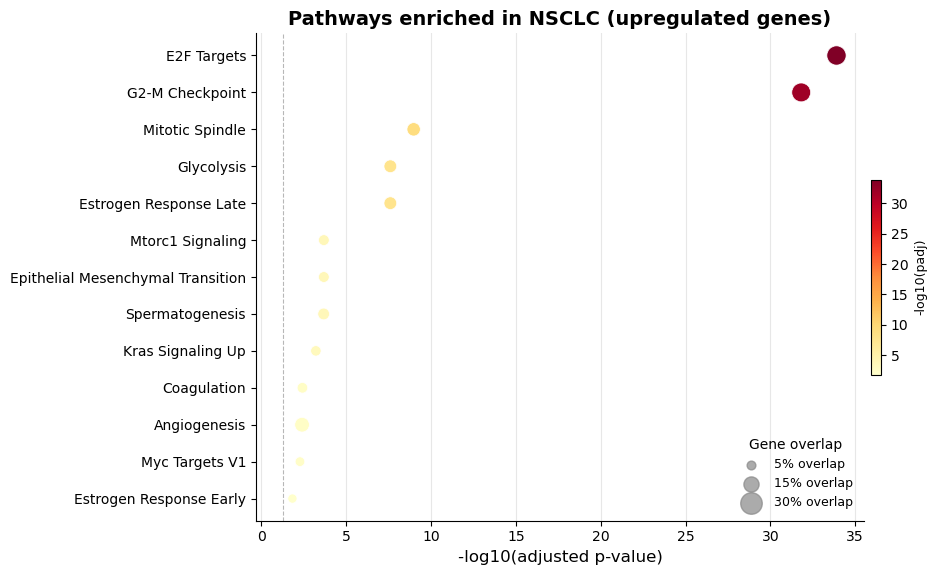

In [17]:
def plot_enrichr(enr, title, top_n=15, save_path=None):
    """Plot top enriched pathways as a dot plot — gseapy 1.2.1"""
    
    df = enr.results.copy()
    
    # 1.2.1 column names
    df = df[df['Adjusted P-value'] < 0.05].copy()
    df = df.head(top_n)
    
    if len(df) == 0:
        print(f"No significant pathways found for: {title}")
        return

    # Clean names
    df['Term'] = (df['Term']
                  .str.replace('HALLMARK_', '', regex=False)
                  .str.replace('_', ' ', regex=False)
                  .str.title())

    df['-log10_padj'] = -np.log10(df['Adjusted P-value'])
    
    # Overlap ratio e.g. "14/200" → 0.07
    df['overlap_ratio'] = df['Overlap'].apply(
        lambda x: int(x.split('/')[0]) / int(x.split('/')[1])
    )

    df = df.sort_values('-log10_padj')

    fig, ax = plt.subplots(figsize=(10, max(5, len(df) * 0.45)))

    scatter = ax.scatter(
        df['-log10_padj'],
        range(len(df)),
        s=df['overlap_ratio'] * 800,
        c=df['-log10_padj'],
        cmap='YlOrRd',
        edgecolors='white',
        linewidths=0.5,
        zorder=3
    )

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['Term'], fontsize=10)
    ax.set_xlabel('-log10(adjusted p-value)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=-np.log10(0.05), color='#888888',
               linestyle='--', linewidth=0.8, alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)

    cbar = plt.colorbar(scatter, ax=ax, shrink=0.4, pad=0.01)
    cbar.set_label('-log10(padj)', fontsize=9)

    for ratio, label in [(0.05, '5%'), (0.15, '15%'), (0.30, '30%')]:
        ax.scatter([], [], s=ratio * 800, c='#888888',
                   label=f'{label} overlap', alpha=0.7)
    ax.legend(title='Gene overlap', fontsize=9,
              loc='lower right', frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# Plot cancer pathways
plot_enrichr(
    enr_cancer,
    title='Pathways enriched in NSCLC (upregulated genes)',
    save_path='figures/04_pathways_cancer.png'
)

Saved: figures/05_pathways_normal.png


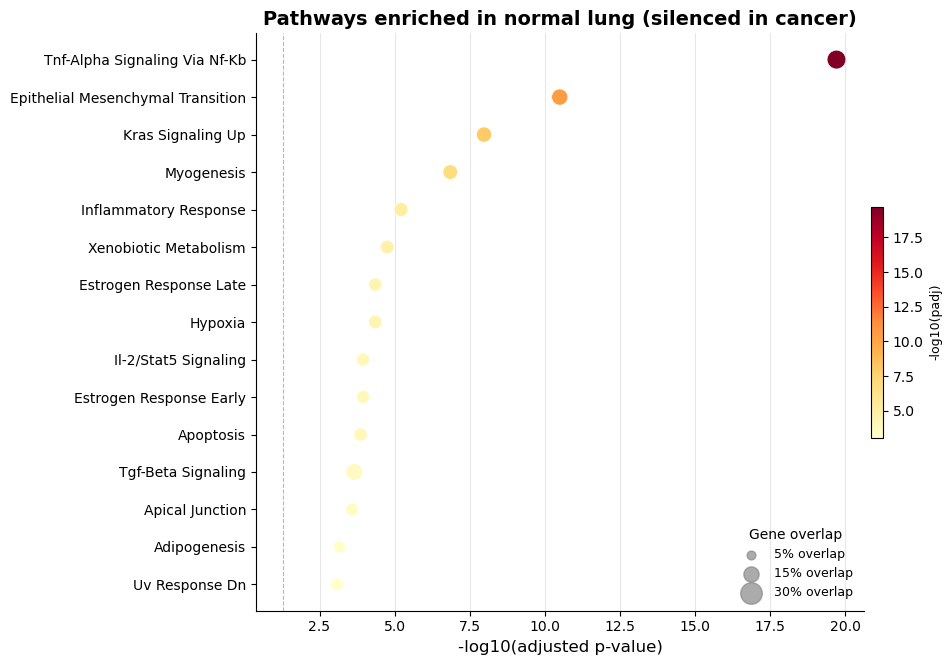

In [18]:
# Run enrichr for normal
enr_normal = gp.enrichr(
    gene_list=up_in_normal,
    gene_sets=['MSigDB_Hallmark_2020'],
    organism='human',
    outdir=None,
    verbose=False
)

plot_enrichr(
    enr_normal,
    title='Pathways enriched in normal lung (silenced in cancer)',
    save_path='figures/05_pathways_normal.png'
)

In [19]:
# Build the ranked gene list
results_df['rank_score'] = (
    np.sign(results_df['fold_change']) *
    -np.log10(results_df['p_value'] + 1e-300)
)

ranked = (results_df
          .set_index('gene')['rank_score']
          .sort_values(ascending=False)
          .dropna())

print(f"Ranked genes: {len(ranked):,}")
print(f"Top 5:\n{ranked.head()}")
print(f"Bottom 5:\n{ranked.tail()}")

# Run GSEA preranked — 1.2.1 syntax
gsea_results = gp.prerank(
    rnk=ranked,
    gene_sets='MSigDB_Hallmark_2020',
    seed=42,
    permutation_num=100,
    outdir=None,
    verbose=False
)

# Show results
gsea_df = gsea_results.res2d.sort_values('NES', ascending=False)
print("\nTop pathways by NES:")
print(gsea_df[['Term', 'NES', 'NOM p-val', 'FDR q-val']].head(10).to_string())

2026-06-06 16:23:34,702 [WARNING] Duplicated values found in preranked stats: 0.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Ranked genes: 15,084
Top 5:
gene
PYCR1       43.662761
ALDH18A1    42.223047
SPP1        38.377382
RCC1        38.290997
FAM136A     38.007153
Name: rank_score, dtype: float64
Bottom 5:
gene
SCUBE1     -45.593498
STX11      -46.633597
C13orf36   -49.209904
CCBE1      -49.676907
GPM6A      -53.736703
Name: rank_score, dtype: float64

Top pathways by NES:
                         Term       NES  NOM p-val  FDR q-val
0                 E2F Targets  2.773244       0.01       0.01
1             G2-M Checkpoint  2.590149       0.01       0.01
2              Myc Targets V1  2.551507       0.01       0.01
4                  Glycolysis  2.219916       0.01       0.01
6              Myc Targets V2  2.102701       0.01       0.01
8            mTORC1 Signaling  2.020693       0.01       0.01
10  Unfolded Protein Response  1.944016       0.01       0.01
13                 DNA Repair   1.83952       0.01       0.01
14            Spermatogenesis  1.773838       0.01       0.01
20  Oxidative Phosphoryl

Saved: figures/06_gsea_summary.png


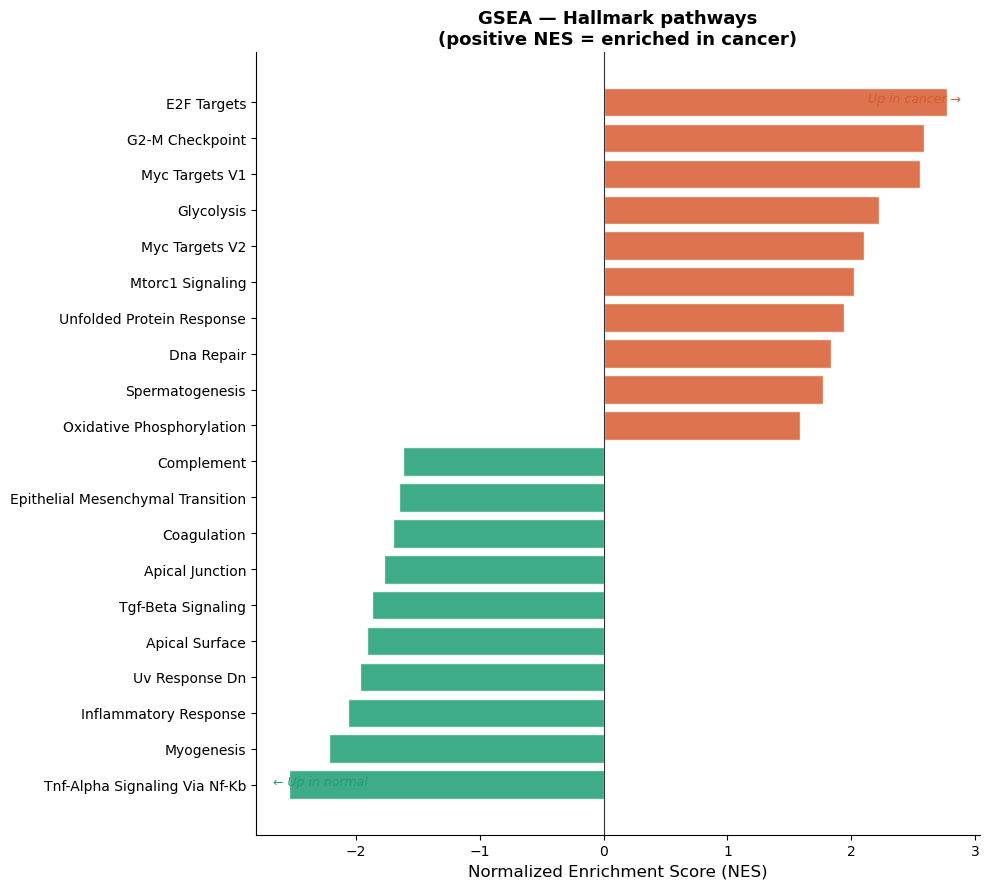

In [20]:
def plot_gsea_summary(gsea_results, top_n=20, save_path=None):
    df = gsea_results.res2d.copy()
    df = df[df['FDR q-val'] < 0.25]
    df['Term'] = (df['Term']
                  .str.replace('HALLMARK_', '', regex=False)
                  .str.replace('_', ' ', regex=False)
                  .str.title())
    df = df.sort_values('NES')

    # Top and bottom N
    half = top_n // 2
    plot_df = pd.concat([df.head(half), df.tail(half)]).drop_duplicates()
    plot_df = plot_df.sort_values('NES')

    colours = ['#1D9E75' if x < 0 else '#D85A30' for x in plot_df['NES']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.45)))

    ax.barh(range(len(plot_df)), plot_df['NES'],
            color=colours, alpha=0.85, edgecolor='white')

    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df['Term'], fontsize=10)
    ax.axvline(x=0, color='#333333', linewidth=0.8)
    ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=12)
    ax.set_title('GSEA — Hallmark pathways\n(positive NES = enriched in cancer)',
                 fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xlim = ax.get_xlim()
    ax.text(xlim[1] * 0.95, len(plot_df) - 1,
            'Up in cancer →', ha='right', fontsize=9,
            color='#D85A30', style='italic')
    ax.text(xlim[0] * 0.95, 0,
            '← Up in normal', ha='left', fontsize=9,
            color='#1D9E75', style='italic')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_gsea_summary(gsea_results, save_path='figures/06_gsea_summary.png')